In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


STEPS:
1. Data overview
2. Brief cleaning (filtering, changing col types, removing features, adding features)
3. EDA (visualizations)
4. Splitting data
5. Data preprocessing (imputing, encoding, transforming)
6. Modeling

GOAL:
- Segment customers based on purchase behavior with K-means clustering

In [3]:
df = pd.read_csv('customer_segmentation_data.csv')
df.drop(columns=['Segmentation Group', 'Customer ID'], inplace=True)

In [4]:
df.head()

,Age,Gender,Marital Status,Education Level,Geographic Information,Occupation,Income Level,Behavioral Data,Purchase History,Interactions with Customer Service,Insurance Products Owned,Coverage Amount,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language
0,23,Female,Married,Associate Degree,Mizoram,Entrepreneur,70541,policy5,04-10-2018,Phone,policy2,366603,2749,Group,Email,In-Person Meeting,Afternoon,English
1,26,Male,Widowed,Doctorate,Goa,Manager,54168,policy5,11-06-2018,Chat,policy1,780236,1966,Group,Mail,In-Person Meeting,Morning,French
2,29,Female,Single,Associate Degree,Rajasthan,Entrepreneur,73899,policy5,06-05-2021,Email,policy3,773926,4413,Group,Email,Mail,Evening,German
3,20,Male,Divorced,Bachelor's Degree,Sikkim,Entrepreneur,63381,policy5,09-02-2018,Chat,policy2,787815,4342,Family,Text,In-Person Meeting,Anytime,French
4,25,Female,Separated,Bachelor's Degree,West Bengal,Manager,38794,policy1,09-10-2018,Chat,policy4,366506,1276,Family,Email,Text,Weekends,English


In [5]:
print(f'Data shape:')
print(f'{df.shape}\n----------------')

display(df.describe().T)

Data shape:
(53503, 18)
----------------


,count,mean,std,min,25%,50%,75%,max
Age,53503.0,44.140945,15.079486,18.0,32.0,43.0,57.0,70.0
Income Level,53503.0,82768.324318,36651.075670,20001.0,51568.5,80719.0,115973.5,149999.0
Coverage Amount,53503.0,492580.789638,268405.505571,50001.0,249613.5,477261.0,739124.0,1000000.0
Premium Amount,53503.0,3023.702447,1285.834295,500.0,1817.0,3194.0,4311.5,5000.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53503 entries, 0 to 53502
Data columns (total 18 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Age                                 53503 non-null  int64 
 1   Gender                              53503 non-null  object
 2   Marital Status                      53503 non-null  object
 3   Education Level                     53503 non-null  object
 4   Geographic Information              53503 non-null  object
 5   Occupation                          53503 non-null  object
 6   Income Level                        53503 non-null  int64 
 7   Behavioral Data                     53503 non-null  object
 8   Purchase History                    53503 non-null  object
 9   Interactions with Customer Service  53503 non-null  object
 10  Insurance Products Owned            53503 non-null  object
 11  Coverage Amount                     53503 non-null  in

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,53503.0,44.140945,15.079486,18.0,32.0,43.0,57.0,70.0
Income Level,53503.0,82768.324318,36651.075670,20001.0,51568.5,80719.0,115973.5,149999.0
Coverage Amount,53503.0,492580.789638,268405.505571,50001.0,249613.5,477261.0,739124.0,1000000.0
Premium Amount,53503.0,3023.702447,1285.834295,500.0,1817.0,3194.0,4311.5,5000.0


In [8]:
missing_vals = df.isna().sum()
missing_vals

Age                                   0
Gender                                0
Marital Status                        0
Education Level                       0
Geographic Information                0
Occupation                            0
Income Level                          0
Behavioral Data                       0
Purchase History                      0
Interactions with Customer Service    0
Insurance Products Owned              0
Coverage Amount                       0
Premium Amount                        0
Policy Type                           0
Customer Preferences                  0
Preferred Communication Channel       0
Preferred Contact Time                0
Preferred Language                    0
dtype: int64

In [9]:
features = df.columns

for i, col in enumerate(features):
    name = col.replace(' ','_')
    print(f'Unique values in column {name.upper()}:\n{df[col].unique()}')
    print(f'Total unique values: {df[col].nunique()}')
    print('-'*50)
    print('\n')



Unique values in column AGE:
[23 26 29 20 25 41 55 35 43 32 69 47 31 65 64 53 48 62 58 56 68 70 63 45
 51 52 27 33 38 40 54 24 36 42 30 34 67 44 57 37 59 61 21 46 19 39 60 49
 22 28 50 66 18]
Total unique values: 53
--------------------------------------------------


Unique values in column GENDER:
['Female' 'Male']
Total unique values: 2
--------------------------------------------------


Unique values in column MARITAL_STATUS:
['Married' 'Widowed' 'Single' 'Divorced' 'Separated']
Total unique values: 5
--------------------------------------------------


Unique values in column EDUCATION_LEVEL:
['Associate Degree' 'Doctorate' "Bachelor's Degree" "Master's Degree"
 'High School Diploma']
Total unique values: 5
--------------------------------------------------


Unique values in column GEOGRAPHIC_INFORMATION:
['Mizoram' 'Goa' 'Rajasthan' 'Sikkim' 'West Bengal' 'Uttar Pradesh'
 'Himachal Pradesh' 'Manipur' 'Gujarat' 'Andaman and Nicobar Islands'
 'Tripura' 'Nagaland' 'Karnataka' 'Odi

In [10]:
df = df.drop_duplicates()

- We also drop Preferred Communication Channel and Contact Time as these are just preferences, not customers behavior (We want to cluster customers based on purchase behavior) and we drop Gender, Occupation, Education Level, Marital Status and Geographic Information also (Demographic, not behavioral)

In [11]:
cols_to_drop = ['Gender', 'Marital Status', 'Preferred Communication Channel', 'Preferred Contact Time', 'Preferred Language', 'Interactions with Customer Service', 'Customer Preferences', 'Education Level', 'Occupation', 'Geographic Information']
df = df.drop(columns=cols_to_drop)

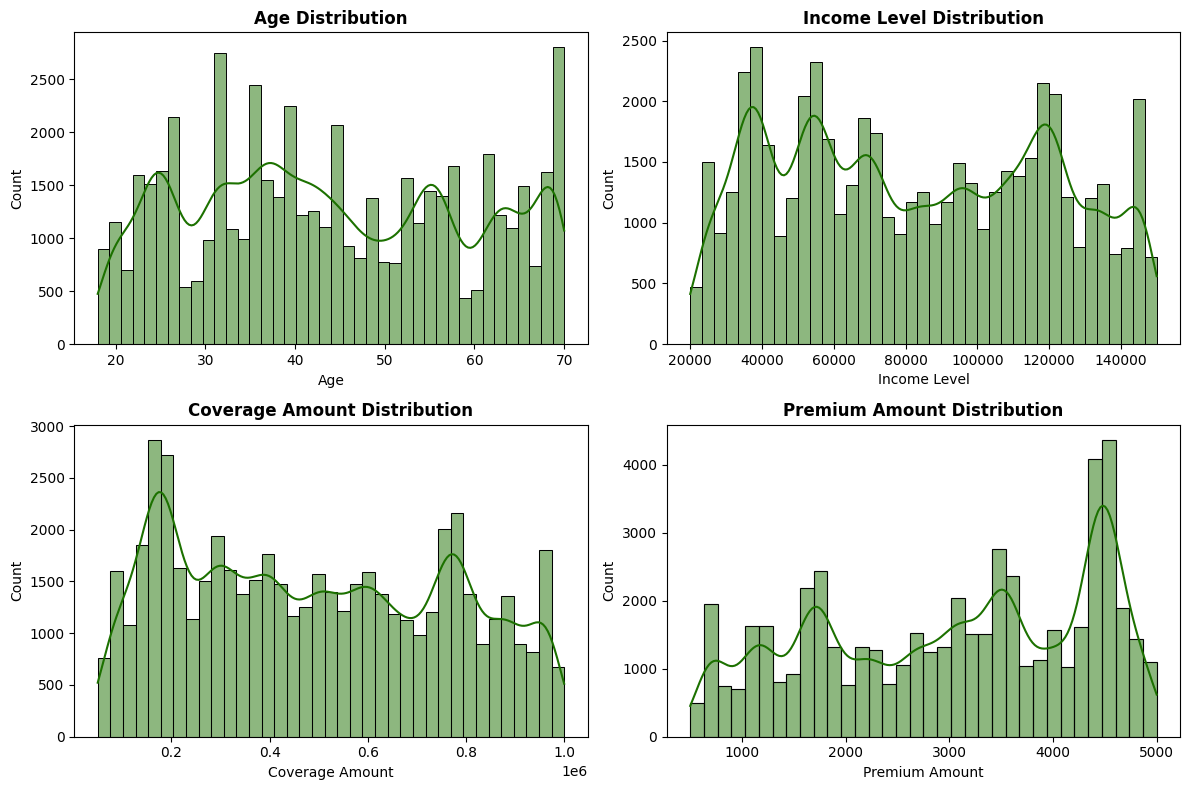

In [12]:
num = df.select_dtypes('int64')


fig, ax = plt.subplots(2,2,figsize=(12,8))

for i ,f in enumerate(num):
    sns.histplot(data=df[f], kde=True, ax=ax.flat[i], color="#1C7100")
    ax.flat[i].set_title(f'{f} Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

In [13]:
df.select_dtypes('number').skew().sort_values(ascending=False)

Coverage Amount    0.165374
Age                0.116046
Income Level       0.109402
Premium Amount    -0.274183
dtype: float64

C:\Users\MSI\AppData\Local\Temp\ipykernel_27268\3716469653.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=f, ax=ax.flat[i], palette='tab10')
C:\Users\MSI\AppData\Local\Temp\ipykernel_27268\3716469653.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=f, ax=ax.flat[i], palette='tab10')


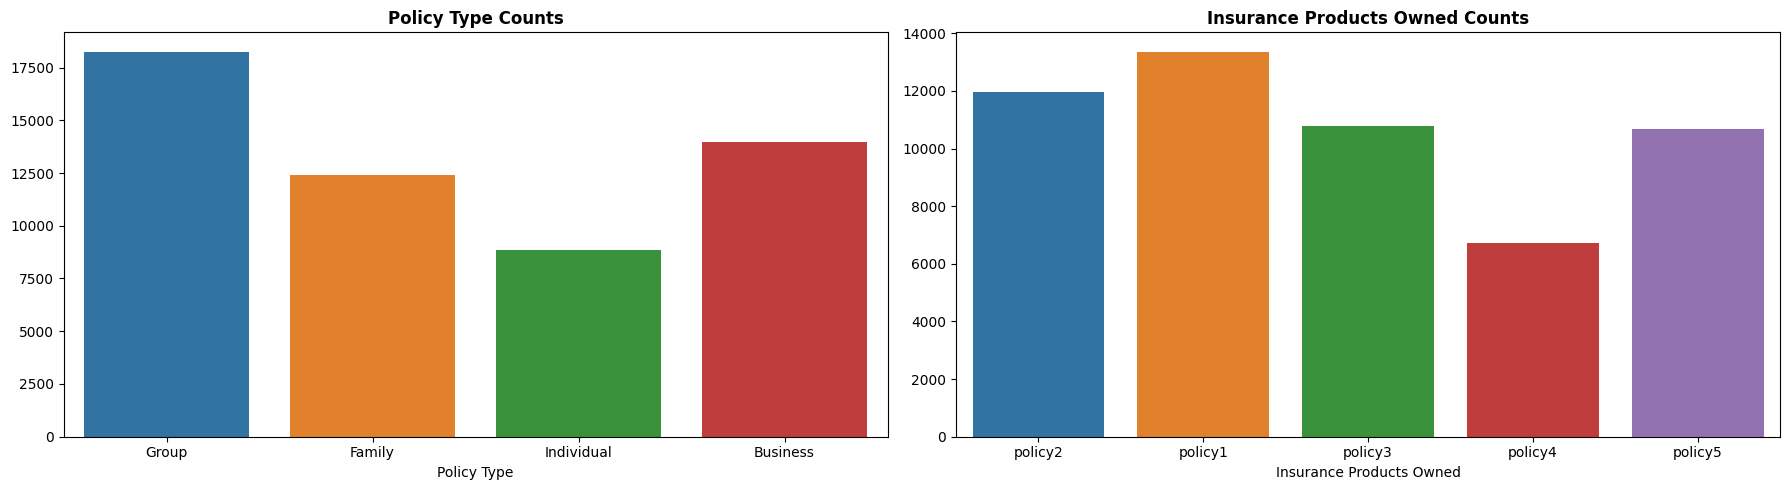

In [14]:
feat_to_plot = ['Policy Type', 'Insurance Products Owned']

fig, ax = plt.subplots(1,2,figsize=(18,5))

for i, f in enumerate(feat_to_plot):
    sns.countplot(data=df, x=f, ax=ax.flat[i], palette='tab10')
    ax.flat[i].set_title(f'{f} Counts', fontweight='bold')
    ax.flat[i].set_ylabel('')

plt.tight_layout()

C:\Users\MSI\AppData\Local\Temp\ipykernel_27268\2752509147.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly, x='month', y='purchases', ax=ax[1], palette='tab10')


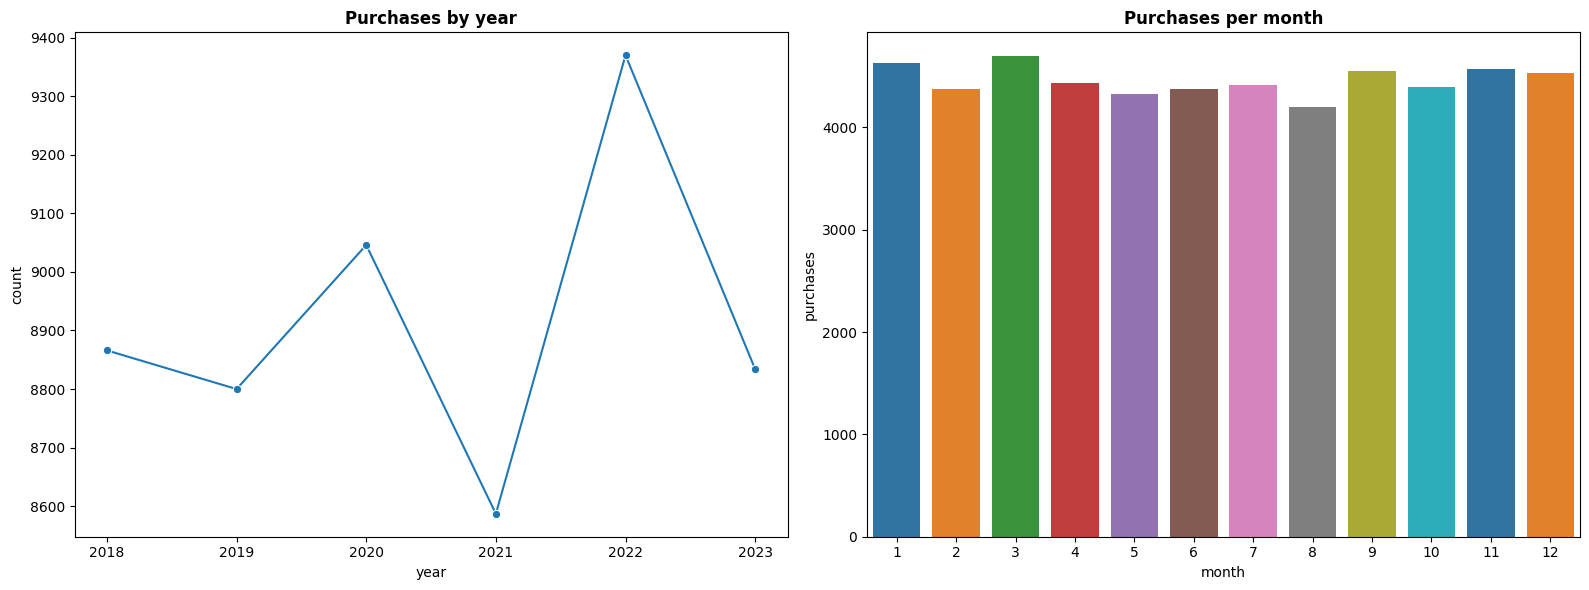

In [15]:
mask_slash = df['Purchase History'].str.contains('/')
mask_dash  = df['Purchase History'].str.contains('-')

df.loc[mask_slash, 'Purchase History'] = pd.to_datetime(
    df.loc[mask_slash, 'Purchase History'], format='%m/%d/%Y')

df.loc[mask_dash, 'Purchase History'] = pd.to_datetime(
    df.loc[mask_dash, 'Purchase History'], format='%m-%d-%Y')

df['Purchase History'] = pd.to_datetime(df['Purchase History'])

yearly = df.groupby(df['Purchase History'].dt.year).size().reset_index()
yearly.columns = ['year', 'count']
yearly['year'] = yearly['year'].astype('str')

monthly = df.groupby(df['Purchase History'].dt.month).size().reset_index()
monthly.columns = ['month', 'purchases']

fig, ax = plt.subplots(1,2,figsize=(16,6))

sns.lineplot(data=yearly, x='year', y='count', marker='o', ax=ax[0])
ax[0].set_title('Purchases by year', fontweight='bold')

sns.barplot(data=monthly, x='month', y='purchases', ax=ax[1], palette='tab10')
ax[1].set_title('Purchases per month', fontweight='bold')

plt.tight_layout()
plt.show()




C:\Users\MSI\AppData\Local\Temp\ipykernel_27268\2689937769.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Policy Type', y='Premium Amount', palette='tab10', ax=ax[0])
C:\Users\MSI\AppData\Local\Temp\ipykernel_27268\2689937769.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Policy Type', y='Coverage Amount', palette='tab10', ax=ax[1])


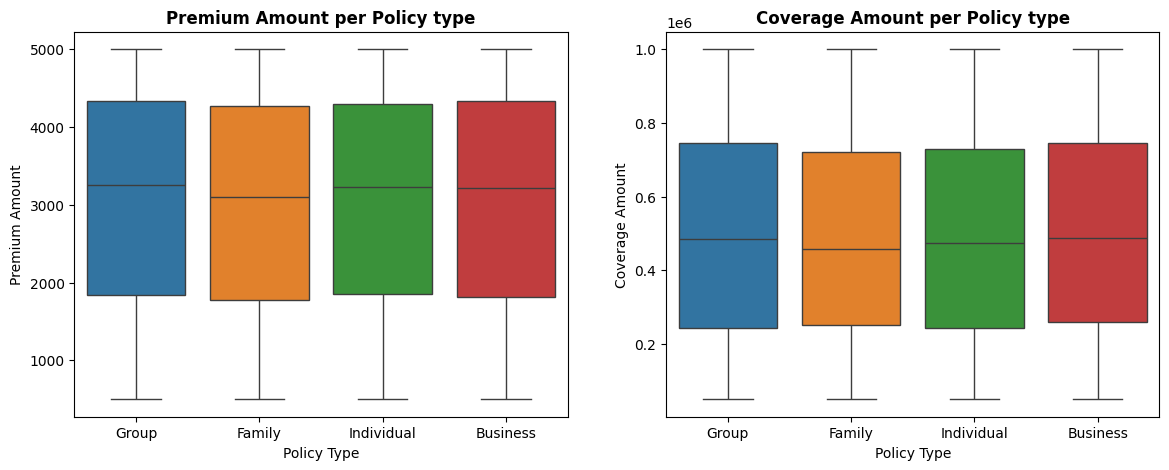

In [16]:
fig, ax = plt.subplots(1,2,figsize=(14,5))

sns.boxplot(data=df, x='Policy Type', y='Premium Amount', palette='tab10', ax=ax[0])
sns.boxplot(data=df, x='Policy Type', y='Coverage Amount', palette='tab10', ax=ax[1])

ax[0].set_title('Premium Amount per Policy type', fontweight='bold')
ax[1].set_title('Coverage Amount per Policy type', fontweight='bold')

plt.show()

C:\Users\MSI\AppData\Local\Temp\ipykernel_27268\1790236960.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Insurance Products Owned', y='Coverage Amount', palette='tab10')


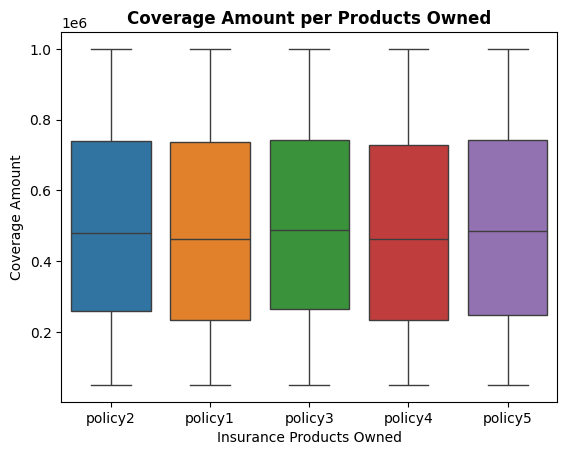

In [17]:
sns.boxplot(data=df, x='Insurance Products Owned', y='Coverage Amount', palette='tab10')
plt.title('Coverage Amount per Products Owned', fontweight='bold')
plt.show()

C:\Users\MSI\AppData\Local\Temp\ipykernel_27268\4182411775.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Insurance Products Owned', y='Premium Amount', palette='tab10')


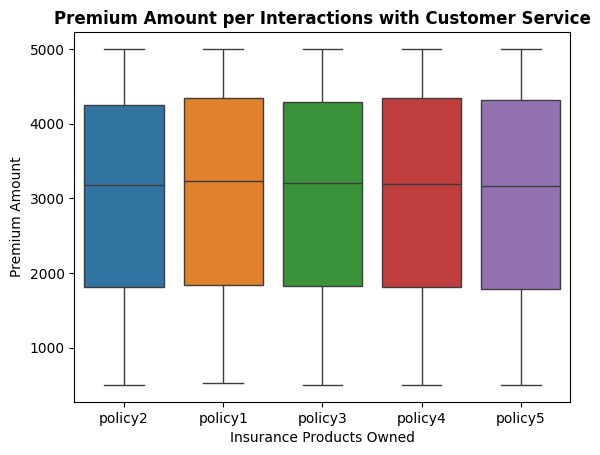

In [18]:
sns.boxplot(data=df, x='Insurance Products Owned', y='Premium Amount', palette='tab10')
plt.title('Premium Amount per Interactions with Customer Service', fontweight='bold')
plt.show()

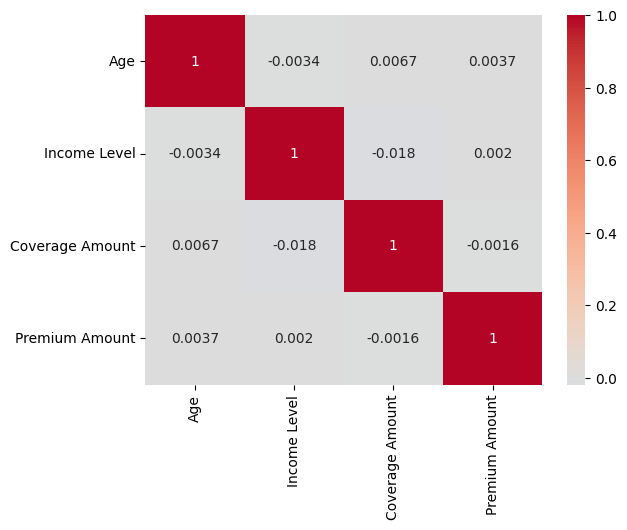

In [19]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', center=0)
plt.show()

In [20]:
df.head()

,Age,Income Level,Behavioral Data,Purchase History,Insurance Products Owned,Coverage Amount,Premium Amount,Policy Type
0,23,70541,policy5,2018-04-10,policy2,366603,2749,Group
1,26,54168,policy5,2018-11-06,policy1,780236,1966,Group
2,29,73899,policy5,2021-06-05,policy3,773926,4413,Group
3,20,63381,policy5,2018-09-02,policy2,787815,4342,Family
4,25,38794,policy1,2018-09-10,policy4,366506,1276,Family


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53503 entries, 0 to 53502
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Age                       53503 non-null  int64         
 1   Income Level              53503 non-null  int64         
 2   Behavioral Data           53503 non-null  object        
 3   Purchase History          53503 non-null  datetime64[ns]
 4   Insurance Products Owned  53503 non-null  object        
 5   Coverage Amount           53503 non-null  int64         
 6   Premium Amount            53503 non-null  int64         
 7   Policy Type               53503 non-null  object        
dtypes: datetime64[ns](1), int64(4), object(3)
memory usage: 3.3+ MB


- Feature Engineering

In [22]:
latest_date = df['Purchase History'].max()
df['recency'] = (latest_date - df['Purchase History']).dt.days
df = df.drop(columns='Purchase History')

In [23]:
df.head()

,Age,Income Level,Behavioral Data,Insurance Products Owned,Coverage Amount,Premium Amount,Policy Type,recency
0,23,70541,policy5,policy2,366603,2749,Group,2088
1,26,54168,policy5,policy1,780236,1966,Group,1878
2,29,73899,policy5,policy3,773926,4413,Group,936
3,20,63381,policy5,policy2,787815,4342,Family,1943
4,25,38794,policy1,policy4,366506,1276,Family,1935


In [24]:
categorical_features = df.select_dtypes('object').columns.tolist()

for i, col in enumerate(categorical_features):
    name = col.replace(' ','_')
    print(f'Unique values in column {name.upper()}:\n{df[col].unique()}')
    print(f'Total unique values: {df[col].nunique()}')
    print('-'*50)
    print('\n')

Unique values in column BEHAVIORAL_DATA:
['policy5' 'policy1' 'policy3' 'policy2' 'policy4']
Total unique values: 5
--------------------------------------------------


Unique values in column INSURANCE_PRODUCTS_OWNED:
['policy2' 'policy1' 'policy3' 'policy4' 'policy5']
Total unique values: 5
--------------------------------------------------


Unique values in column POLICY_TYPE:
['Group' 'Family' 'Individual' 'Business']
Total unique values: 4
--------------------------------------------------




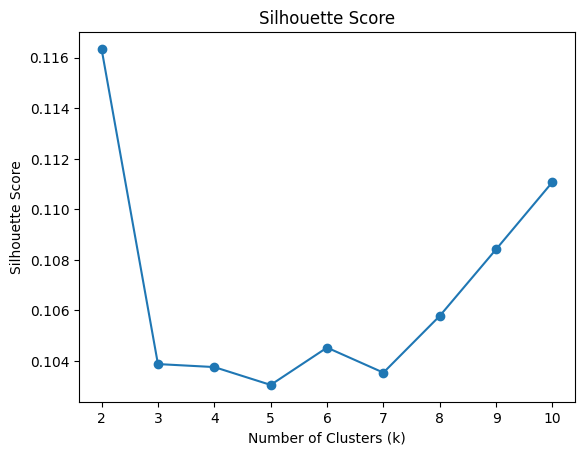

In [ ]:
num_features = df.select_dtypes('number').columns.tolist()

num_pipeline = Pipeline([
    ('scale', StandardScaler())
])

cat_pipeline = Pipeline([
    ('encode', OneHotEncoder(sparse_output=False, drop='first'))
])

preprocessor = ColumnTransformer([
    ('num_f', num_pipeline, num_features),
    ('cat_f', cat_pipeline, categorical_features), 
])


In [ ]:
X_preprocessed = preprocessor.fit_transform(df)

pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_preprocessed)

inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_reduced)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_reduced, labels))

plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.show()

In [29]:
kmeans_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('pca', PCA(n_components=0.95)),
    ('model', KMeans(n_clusters=2,
                      random_state=42,
                      n_init=10
                      ))
])

final_clusters = kmeans_pipeline.fit_predict(df)
df['cluster'] = final_clusters

In [30]:
print(df['cluster'].value_counts())

cluster
1    28109
0    25394
Name: count, dtype: int64


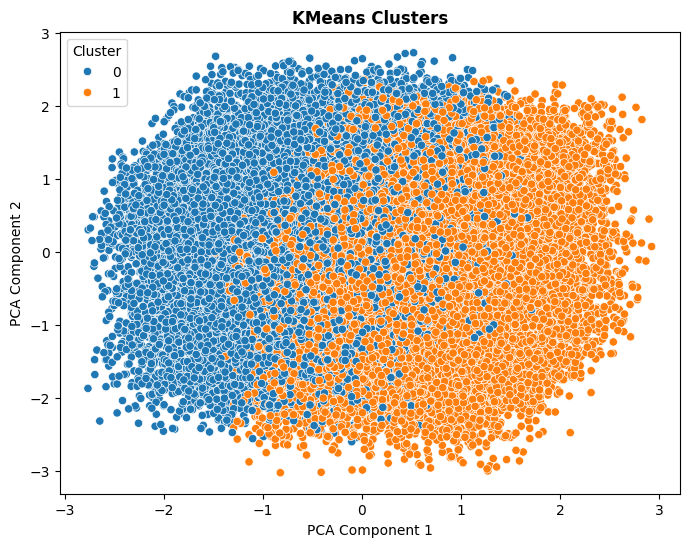

In [33]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_reduced)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=final_clusters, palette='tab10')
plt.title('KMeans Clusters', fontweight='bold')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()

In [ ]:
score = silhouette_score(X_reduced, final_clusters)
print(f'Silhouette Score: {score}')

Silhouette Score: 0.11634887939437423


: 